In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = sns.load_dataset("titanic")

In [2]:
data.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [3]:
data

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [4]:
data = data.drop(columns=['sibsp','embark_town','embarked','parch','adult_male','class','alone','deck','who'],axis=1)

In [5]:
data.columns

Index(['survived', 'pclass', 'sex', 'age', 'fare', 'alive'], dtype='object')

In [6]:
data

,survived,pclass,sex,age,fare,alive
0,0,3,male,22.0,7.2500,no
1,1,1,female,38.0,71.2833,yes
2,1,3,female,26.0,7.9250,yes
3,1,1,female,35.0,53.1000,yes
4,0,3,male,35.0,8.0500,no
...,...,...,...,...,...,...
886,0,2,male,27.0,13.0000,no
887,1,1,female,19.0,30.0000,yes
888,0,3,female,NaN,23.4500,no
889,1,1,male,26.0,30.0000,yes


In [7]:
from sklearn.preprocessing import LabelEncoder

lb = LabelEncoder()

data.columns

Index(['survived', 'pclass', 'sex', 'age', 'fare', 'alive'], dtype='object')

In [8]:
columns_to_encode = [ 'sex', 'alive']
for col in columns_to_encode:
    data[col] = lb.fit_transform(data[col])

In [9]:
data['sex'].value_counts()

sex
1    577
0    314
Name: count, dtype: int64

In [10]:
data.isna().sum()


survived      0
pclass        0
sex           0
age         177
fare          0
alive         0
dtype: int64

In [11]:
data['sex'].mode()

0    1
Name: sex, dtype: int64

In [12]:
data['age'].mode()

0    24.0
Name: age, dtype: float64

In [13]:
data['age'].fillna(data['age'].mean(), inplace=True)

/tmp/ipykernel_6885/1829737370.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['age'].fillna(data['age'].mean(), inplace=True)


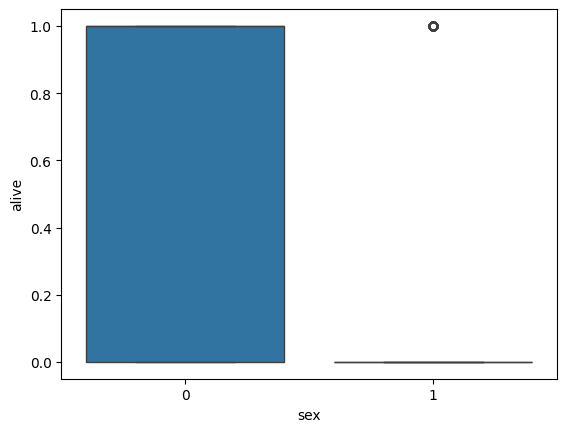

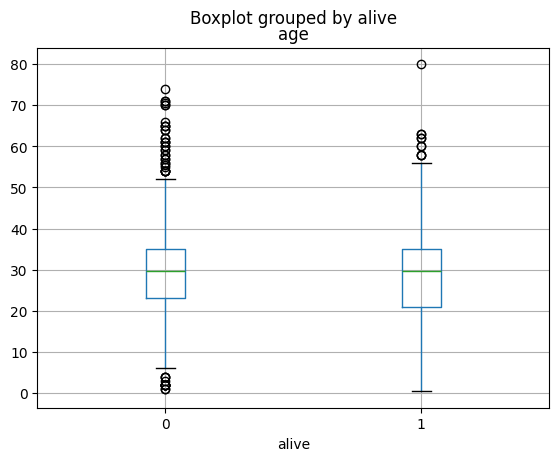

In [14]:
sns.boxplot(x='sex', y='alive', data=data)
plt.show()

data.boxplot(column='age', by='alive')
plt.show()

In [15]:
# plt.figure(figsize=(8, 6)) 
# sns.heatmap(data.corr(),annot=True)
# plt.show()

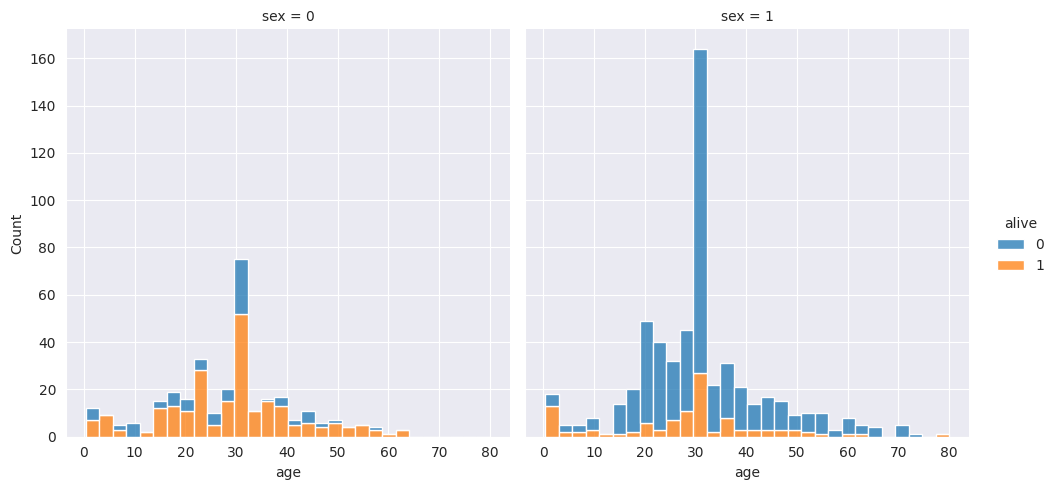

In [16]:
sns.set_style('darkgrid')

sns.displot(data=data,
    x='age',
    hue='alive',
    col='sex',
    kind='hist',
    multiple='stack',
)
plt.show()